# Is het verdamping?

In dit experiment is er een verwarmingselement in een met water gevulde maatbeker gestopt. Elke minuut is de temperatuur van het water gemeten. Deze metingen zijn opgeslagen in [tempmetingen.csv](tempmetingen.csv).

Verder is gegeven dat: 
$m_{maatbeker} = 820.8 \mathrm{gr}$  
$m_{maatbeker + water, start} = 1292.9 \mathrm{gr}$  
$m_{maatbeker + water, eind} = 1274.9 \mathrm{gr}$

Het moge duidelijk zijn dat er water is 'verdwenen'. Ook is de eindtemperatuur van het water niet gelijk aan een proces waarbij verdamping en eventuele warmteverliezen niet meegenomen worden. 

```{exercise}
Onderzoek het proces door:
1. De plot van de metingen te maken, inclusief een verwachte trendlijn voor de temperatuur van het water als al de toegevoerde warmte gaat zitten in het water.
2. Bepaal of de totale hoeveelheid toegevoegde energie correspondeert met de opwarming en verdamping van het water, geef daarbij de aannames die je doet.
3. Geef aanbevelingen voor een verbetering van het experiment om (nog) beter het thermodynamische proces te kunnen onderzoeken en beschrijven.
```

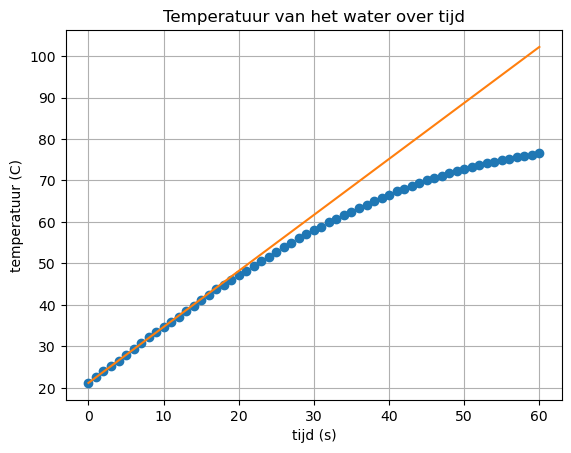

In [15]:
import numpy as np
import matplotlib.pyplot as plt

#gegeven massa's
m_maatbeker = 820.8 #g
m0 = (1292.9 - m_maatbeker)/1000 #kg
m1 = (1274.9 - m_maatbeker)/1000 #kg
dm = m0 - m1 #kg

#constanten
c_water = 4186 #J/kg*K

#tijd in seconden
ts = 60*t

#data inlezen
t, T = np.loadtxt("tempmetingen-0203356cbb854ce862d0304505c4ede5.csv", delimiter=';', skiprows=1, unpack=True)

#eerste 10 meetpunten gebruiken voor bepaling dT/dt
N = 10  #aantal meetpunten
dTdt = (T[N] - T[0]) / (ts[N] - ts[0])  #°C/s

#vermogen
P = m0 * c_water * dTdt  #Watt

#verwachte temperatuurstijging zonder verdamping
T_verwacht = T[0] + (P/(m0*c_water)) * ts

#data plotten
plt.plot(t, T, 'o', label='meting')
plt.plot(t, T_verwacht, '-', label='verwacht (zonder verdamping)')
plt.xlabel('tijd (s)')
plt.ylabel('temperatuur (C)')
plt.title('Temperatuur van het water over tijd')
plt.grid()
plt.show()

In [19]:
#totale toegevoegde energie
E_toegevoegd = P * (ts[-1] - ts[0])  #Joule

#energie voor opwarming
Q_opwarmen = m0 * c_water * (T[-1] - T[0])  #Joule

#energie voor verdamping
L_v = 2.4e6 #J/kg
Q_verdamping = dm * L_v

print('De toegevoegde energie is:', round(E_toegevoegd/1000, 2), 'kJ')
print('De energie gebruikt voor opwarming is:', round(Q_opwarmen/1000, 2), 'kJ')
print('De energie gebruikt voor verdamping is:', round(Q_verdamping/1000, 2), 'kJ')

De toegevoegde energie is: 160.07 kJ
De energie gebruikt voor opwarming is: 109.48 kJ
De energie gebruikt voor verdamping is: 43.2 kJ


## Aanbevelingen

- Meet het elektrisch vermogen direct, zodat de toegevoerde energie niet geschat hoeft te worden.
- Isoleer de maatbeker (voorkomt warmteverlies)
- Meet de massa van het water, want dan kan je de verdamping over tijd bepalen.